# From Stochastic Simulation to Market-Based Execution
### Adrián Vázquez
---

## Objective

In the previous stage, execution strategies were evaluated under simulated price dynamics using an Arithmetic Brownian Motion.

In this notebook, we transition to a **market-based setting**, where execution is evaluated using **real intraday price and volume data**.

The objective is to assess how theoretical execution models behave when exposed to actual market conditions.

---

## Framework

We consider a discrete execution problem over a fixed horizon:

- Total shares to execute: $Q$
- Time horizon divided into $N$ intervals of length $\tau = T/N$
- Execution schedule: $\{n_k\}_{k=1}^{N}$

Using real market data:

- $S_k$ = observed mid price at time $k$
- $V_k$ = observed market volume at time $k$

Execution prices incorporate market impact:

$$
P_k = S_k + \gamma \sum_{j<k} n_j + \eta \frac{n_k}{\tau}
$$

---

## What Changes from the Simulation?

Previously:

$$
S_{k+1} = S_k + \sigma \sqrt{\tau} \epsilon_k
$$

Now:

- $S_k$ is directly observed from the market
- Volatility $\sigma$ is estimated from real returns:
  
$$
\hat{\sigma} = \text{std}(\log(S_{k+1}/S_k))
$$

- VWAP schedules are constructed from real volume:

$$
w_k = \frac{V_k}{\sum_{i=1}^{N} V_i}
$$

---

## Research Questions

This notebook aims to answer the following:

### 1. How do execution strategies behave under real market dynamics?

- Does TWAP remain a strong baseline?
- Does VWAP improve when using real volume profiles?

---

### 2. How does real volatility affect execution risk?

- Is the variance of implementation shortfall higher or lower than in simulations?
- Do real price paths exhibit heavier tails?

---

### 3. How does market impact interact with real price movements?

- Does impact dominate execution cost?
- Or do price trends play a larger role?

---

### 4. Which strategy performs better under real data?

We compare:

- **TWAP**
- **VWAP (real volume-based)**
- **Almgren–Chriss**

Using:

- Implementation Shortfall:
  
$$
\text{IS} = \sum_{k=1}^{N} n_k P_k - Q S_0
$$

- Expected Cost
- Execution Risk (standard deviation)

---

### 5. Does the cost-risk trade-off persist in real markets?

- Can we still observe a clear frontier when varying $\lambda$?
- Is the optimal region stable under real data?

---

## Expected Contribution

This notebook bridges the gap between:

- **Theoretical execution models**
- **Real-world trading environments**

By doing so, it allows us to evaluate whether:

> Optimal execution frameworks such as Almgren–Chriss remain effective when applied to real market data.



In [ ]:
# libs
import plotly.io as pio
#pio.renderers.default = "notebook_connected+png" 

from IPython.display import Image, display
import sys
import os
# Add project root to path
sys.path.append(os.path.abspath(".."))

# libs 
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.models.twap import twap_schedule
from src.models.vwap import generate_vwap_schedule
from src.models.inventory_from_schedule import inventory_from_schedule
from src.models.almgren_chriss_shedule import almgren_chriss_schedule
from src.analytics.implementation_shortfall import implementation_shortfall
from src.analytics.get_intraday_prices import get_intraday_prices
from src.models.simulate_brownian_motion_price_path import simulate_brownian_price_path, simulate_multiple_price_paths, simulate_execution_prices

## 1. Real Intraday Market Data

In this section, we introduce the real market dataset used for the execution analysis.

We work with intraday data for the asset:

- Symbol: $\text{SPY}$
- Frequency: $5$-minute intervals
- Variables: $\{\text{Open}, \text{High}, \text{Low}, \text{Close}, \text{Volume}\}$

Let:

$$
S_k = \text{Close price at time } k
$$

This will serve as the **observable mid-price proxy** used in the execution framework.

---

### 1.1 Data Structure

The dataset is indexed by timestamps:

$$
t_k \in \{t_0, t_1, \dots, t_N\}
$$

with constant spacing:

$$
\tau = 5 \text{ minutes}
$$

Each observation corresponds to:

- Price dynamics through $S_k$
- Market activity through traded volume $V_k$

---

### 1.2 Interpretation for Execution

In contrast to the simulated framework:

$$
S_{k+1} = S_k + \sigma \sqrt{\tau} \epsilon_k
$$

we now use:

$$
S_k = \text{observed market price}
$$

This introduces key differences:

- Price paths are no longer Gaussian
- Volatility is time-varying
- Trends and microstructure effects may appear

---

### 1.3 Role of Volume

Volume plays a central role in execution, particularly for VWAP:

$$
w_k = \frac{V_k}{\sum_{i=1}^{N} V_i}
$$

where:

- $V_k$ = traded volume at time $k$
- $w_k$ = execution weight for VWAP

This allows us to construct **data-driven execution schedules**, rather than assuming stylized volume profiles.

---

### 1.4 Objective of This Section

The goal is to prepare the dataset for execution analysis by:

- Defining the price process $S_k$
- Defining the volume process $V_k$
- Establishing the time grid $\{t_k\}$

These elements will be used to simulate execution under real market conditions in the following sections.

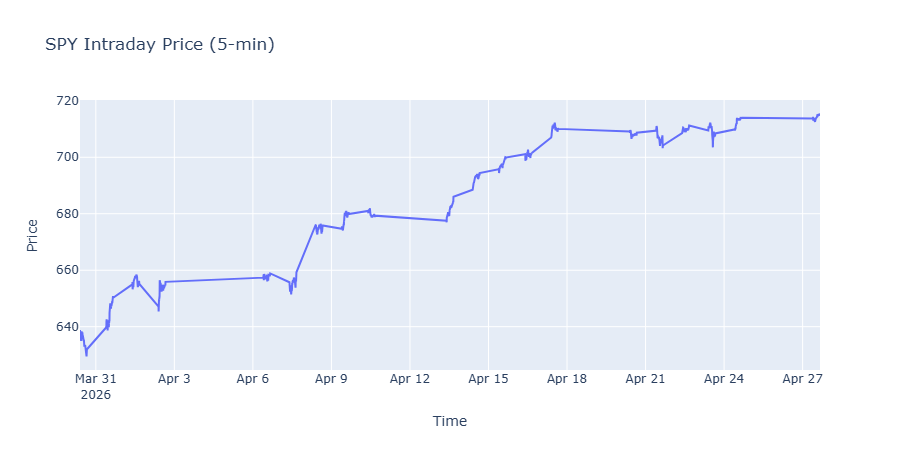

In [ ]:
import plotly.graph_objects as go

API_KEY = #"YOUR_APIKEY"

df_spy_5min = get_intraday_prices(
    symbol="SPY",
    api_key=API_KEY,
    interval="5min",
    outputsize="full",
    extended_hours="false"
    #month = "2025-04"

)

df_spy_5min.head()



fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df_spy_5min.index,
        y=df_spy_5min["Close"],
        mode="lines",
        name="SPY Close Price"
    )
)

fig.update_layout(
    title="SPY Intraday Price (5-min)",
    xaxis_title="Time",
    yaxis_title="Price",
    height=450,
    width=900
)

fig.show()
fig.write_image("../results/plots/spy_intraday_price_5_min.png")
display(Image(filename="../results/plots/spy_intraday_price_5_min.png"))